# Credit scoring

Predict serious loan delinquency within 90 days of issuing a loan. The competition metric is ROC AUC, which measures how well a model ranks risky applications above non risky ones.

The submitted predictions scored 0.8311 on the organizers' undisclosed test set and placed 15th among 228 submissions. This notebook contains the feature construction and ensemble used for that submission.

Run it from the project directory with the five competition CSV files in `data/`. The model parameters are fixed from trial 16 of the saved search study. These settings reproduced the submitted CSV byte for byte in the recorded environment, so a fresh parameter search is not needed. The last cell writes a new file to `outputs/submission.csv` and compares it with the submitted file in the project root.


## 1. Setup and data

The application tables contain one row per loan application. Transactions describe activity before the application, bureau contains external credit history, and previous loans describe earlier borrowing. The raw files stay local.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42
EPSILON = 1e-6

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

UNAVAILABLE_COLUMNS = [
    "internal_decision_code",
    "post_loan_collection_score",
    "days_until_first_overdue",
]


In [2]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
previous_loans = pd.read_csv(DATA_DIR / "previous_loans.csv")

print("train:", train_raw.shape)
print("test:", test.shape)
print("transactions:", transactions.shape)
print("bureau:", bureau.shape)
print("previous_loans:", previous_loans.shape)
train = train_raw.drop_duplicates().reset_index(drop=True)
test = test.copy().reset_index(drop=True)

for label, frame in [("train", train), ("test", test)]:
    for column in ["application_id", "client_id"]:
        assert frame[column].notna().all(), f"Missing {column} in {label}"
        assert frame[column].is_unique, f"Repeated {column} in {label}"
for column in ["application_id", "client_id"]:
    assert set(train[column]).isdisjoint(test[column]), f"Shared {column} between splits"
assert set(train["target"].unique()) == {0, 1}

print("Removed train duplicates:", len(train_raw) - len(train))


train: (6488, 25)
test: (2520, 24)
transactions: (353300, 6)
bureau: (24689, 8)
previous_loans: (12762, 7)
Removed train duplicates: 8


## 2. Data checks and exploration

There are 6480 training applications after removing 8 duplicate rows, and 2520 test applications. About 34 percent of training applications have the target flag. I use stratified folds to keep similar class proportions in each validation split.

Each client appears once, and train and test contain different clients. This makes a split by application reasonable for this dataset. It does not measure performance on future lending periods.


,rows,columns,duplicate_rows
train,6488,25,8
test,2520,24,0
transactions,353300,6,10
bureau,24689,8,6
previous_loans,12762,7,4


,count,share
target,,
0,4262,0.657716
1,2218,0.342284


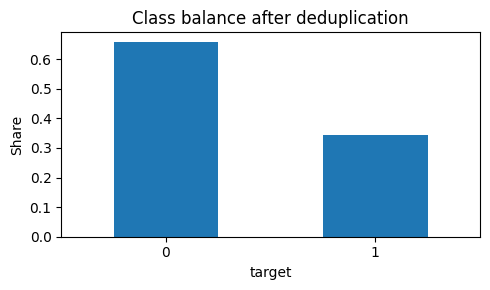

In [3]:
tables = {
    "train": train_raw,
    "test": test,
    "transactions": transactions,
    "bureau": bureau,
    "previous_loans": previous_loans,
}
display(pd.DataFrame({
    name: {"rows": len(frame), "columns": frame.shape[1],
           "duplicate_rows": int(frame.duplicated().sum())}
    for name, frame in tables.items()
}).T)

target_balance = pd.DataFrame({
    "count": train["target"].value_counts().sort_index(),
    "share": train["target"].value_counts(normalize=True).sort_index(),
})
display(target_balance)
ax = target_balance["share"].plot.bar(figsize=(5, 3))
ax.set(title="Class balance after deduplication", xlabel="target", ylabel="Share")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


I compare missing values in the columns shared by train and test. Three columns are entirely missing in test. Two of them, `post_loan_collection_score` and `days_until_first_overdue`, describe events after the loan was issued. Using them would leak information that is unavailable when an application is scored. All three columns are excluded, including from the count of missing application fields.


In [4]:
common_columns = train.columns.intersection(test.columns)
missing_comparison = pd.DataFrame({
    "train_missing_percent": train[common_columns].isna().mean() * 100,
    "test_missing_percent": test[common_columns].isna().mean() * 100,
})
missing_comparison["difference_pp"] = (
    missing_comparison["test_missing_percent"]
    - missing_comparison["train_missing_percent"]
)
missing_comparison = missing_comparison.reindex(
    missing_comparison["difference_pp"].abs().sort_values(ascending=False).index
)
display(missing_comparison.head(10).round(2))
assert test[UNAVAILABLE_COLUMNS].isna().all().all()


,train_missing_percent,test_missing_percent,difference_pp
internal_decision_code,21.17,100.00,78.83
post_loan_collection_score,23.69,100.00,76.31
days_until_first_overdue,28.64,100.00,71.36
hash_id,6.42,9.09,2.67
monthly_income,6.77,9.37,2.59
interest_rate,5.79,8.06,2.27
loan_amount,8.58,6.71,-1.87
loan_term_months,8.10,6.35,-1.75
requested_product,5.90,7.62,1.72
months_at_job,5.96,7.58,1.62


The next plots compare basic numeric features in train and test. Values above the 99th percentile are clipped only for these plots, so the model still sees the original values. Similar distributions are a useful check, but do not prove that the two samples are identical.


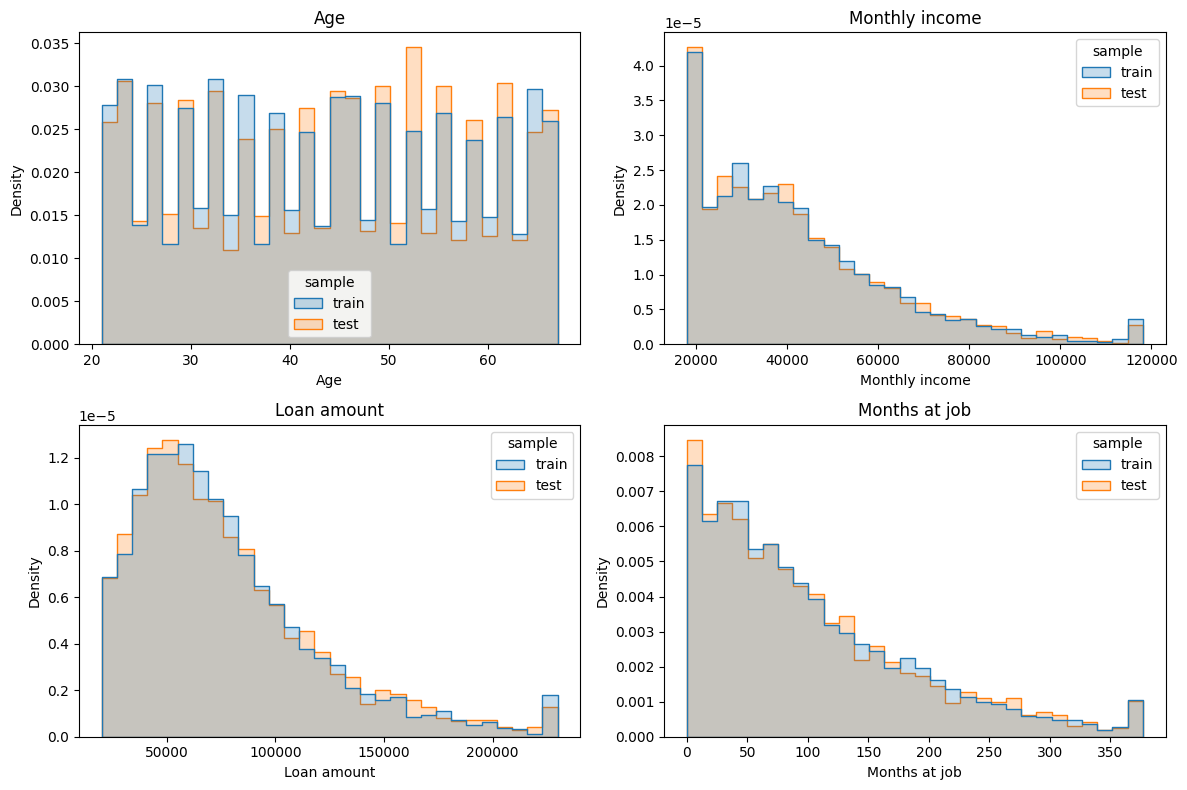

In [5]:
numeric_plots = {
    "age": "Age",
    "monthly_income": "Monthly income",
    "loan_amount": "Loan amount",
    "months_at_job": "Months at job",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (feature, title) in zip(axes.ravel(), numeric_plots.items()):
    plot_data = pd.concat(
        [
            train[[feature]].assign(sample="train"),
            test[[feature]].assign(sample="test"),
        ],
        ignore_index=True,
    )
    upper = plot_data[feature].quantile(0.99)
    plot_data[feature] = plot_data[feature].clip(upper=upper)
    sns.histplot(
        data=plot_data,
        x=feature,
        hue="sample",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set(title=title, xlabel=title, ylabel="Density")

plt.tight_layout()
plt.show()


Employment type and requested product can describe different groups of borrowers. I compare their observed delinquency rates and keep both as categorical features. These are associations in this dataset, not evidence that a category causes delinquency.


In [6]:
for feature in ["employment_type", "requested_product"]:
    grouped = train[[feature, "target"]].copy()
    grouped[feature] = grouped[feature].fillna("missing")
    rates = grouped.groupby(feature)["target"].agg(
        target_rate="mean", observations="size"
    ).sort_values("target_rate", ascending=False)
    display(rates.round(4))


,target_rate,observations
employment_type,,
unemployed,0.7063,429
contractor,0.4399,823
missing,0.3333,465
self_employed,0.3109,846
employee,0.2949,3327
business,0.2610,590


,target_rate,observations
requested_product,,
cash,0.4064,2308
missing,0.3482,382
refinance,0.3184,892
card,0.3052,1373
auto,0.2955,467
pos,0.2892,1058


The history tables have several rows per client. I first check their coverage, then aggregate them into one row per application or client. Counts can separate a short history from a long one, while sums, averages and maxima describe what happened in that history.


In [7]:
all_applicants = pd.concat(
    [
        train[["application_id", "client_id"]],
        test[["application_id", "client_id"]],
    ],
    ignore_index=True,
)

history_counts = pd.DataFrame({
    "transactions": all_applicants["application_id"].map(
        transactions.drop_duplicates().groupby("application_id").size()
    ).fillna(0).astype(int),
    "bureau_accounts": all_applicants["client_id"].map(
        bureau.drop_duplicates().groupby("client_id").size()
    ).fillna(0).astype(int),
    "previous_loans": all_applicants["client_id"].map(
        previous_loans.drop_duplicates().groupby("client_id").size()
    ).fillna(0).astype(int),
})

display(history_counts.describe(percentiles=[0.25, 0.5, 0.75]).T)


,count,mean,std,min,25%,50%,75%,max
transactions,9000.0,39.254444,6.609312,19.0,35.0,39.0,44.0,76.0
bureau_accounts,9000.0,2.742556,1.578431,0.0,2.0,3.0,4.0,10.0
previous_loans,9000.0,1.417556,1.178804,0.0,1.0,1.0,2.0,8.0


## 3. Application features

I add the application month and weekday, along with ratios such as loan amount to income and estimated monthly payment to income. A loan of the same size may imply different repayment pressure for people with different incomes. The estimated payment is simply the principal divided by the term, so it does not include interest.

Technical identifiers are used only for joins and output order. The final feature lists later in the notebook determine what each model actually uses. Some exploratory aggregates are retained here to keep the original feature construction reproducible.


In [8]:
MODEL_DROP_COLUMNS = [
    "target",
    "internal_decision_code",
    "hash_id",
    "application_id",
    "client_id",
    "application_date",
    "post_loan_collection_score",
    "days_until_first_overdue",
    "region_coefficient",
    "region_coefficient_extended",
]

def make_application_features(df):
    features = df.copy()

    missing_count_exclude = {
        "target", "application_id", "client_id", "hash_id", *UNAVAILABLE_COLUMNS
    }
    safe_source_columns = [
        column for column in df.columns if column not in missing_count_exclude
    ]
    features["application_missing_count"] = (
        df[safe_source_columns].isna().sum(axis=1)
    )

    application_date = pd.to_datetime(
        features["application_date"], errors="coerce"
    )
    features["application_month"] = application_date.dt.month
    features["application_weekday"] = application_date.dt.dayofweek

    features["loan_to_income_ratio"] = (
        features["loan_amount"] / (features["monthly_income"] + 1.0)
    )
    features["estimated_monthly_payment"] = (
        features["loan_amount"] / (features["loan_term_months"] + EPSILON)
    )
    features["payment_to_income_ratio"] = (
        features["estimated_monthly_payment"]
        / (features["monthly_income"] + 1.0)
    )
    features["job_to_age_ratio"] = (
        features["months_at_job"] / (features["age"] * 12.0 + 1.0)
    )
    features["income_per_dependent"] = (
        features["monthly_income"] / (features["dependents"] + 1.0)
    )
    return features

train_application_features = make_application_features(train)
test_application_features = make_application_features(test)


## 4. Transaction and credit history

Transactions are grouped by application. I calculate amount statistics, activity counts and the share of transactions in each category. For example, category shares describe spending habits without relying only on the total amount spent.

The dated transaction rows must precede their application. Rows with a missing transaction or application date cannot be checked this way, so their count is reported. I retain them as in the submitted solution and rely on the competition's definition of the history tables.


In [9]:
def make_transaction_features(transactions_df, application_dates):
    tx = transactions_df.drop_duplicates().copy()
    tx["transaction_date"] = pd.to_datetime(
        tx["transaction_date"], errors="coerce"
    )

    dates = application_dates[["application_id", "application_date"]].copy()
    dates["application_date"] = pd.to_datetime(
        dates["application_date"], errors="coerce"
    )
    dates = dates.drop_duplicates("application_id")
    tx = tx.merge(
        dates, on="application_id", how="left", validate="many_to_one"
    )

    known_dates = tx["transaction_date"].notna() & tx["application_date"].notna()
    assert (
        tx.loc[known_dates, "transaction_date"]
        < tx.loc[known_dates, "application_date"]
    ).all(), "A transaction does not precede its application"
    print("Transactions with uncheckable dates:", int((~known_dates).sum()))

    tx["positive_amount"] = tx["amount"].clip(lower=0)
    tx["expense_amount_abs"] = -tx["amount"].clip(upper=0)
    tx["is_incoming"] = (tx["amount"] > 0).astype(float)
    tx["is_outgoing"] = (tx["amount"] < 0).astype(float)
    tx.loc[tx["amount"].isna(), ["is_incoming", "is_outgoing"]] = np.nan
    tx["days_before_application"] = (
        tx["application_date"] - tx["transaction_date"]
    ).dt.days

    aggregated = tx.groupby("application_id", observed=True).agg(
        tx_count=("application_id", "size"),
        tx_amount_sum=("amount", "sum"),
        tx_amount_mean=("amount", "mean"),
        tx_amount_median=("amount", "median"),
        tx_amount_min=("amount", "min"),
        tx_amount_max=("amount", "max"),
        tx_amount_std=("amount", "std"),
        tx_positive_sum=("positive_amount", "sum"),
        tx_expense_abs_sum=("expense_amount_abs", "sum"),
        tx_incoming_share=("is_incoming", "mean"),
        tx_outgoing_share=("is_outgoing", "mean"),
        tx_merchant_risk_mean=("merchant_risk_level", "mean"),
        tx_merchant_risk_max=("merchant_risk_level", "max"),
        tx_category_nunique=("transaction_category", "nunique"),
        tx_active_days=("transaction_date", "nunique"),
        tx_last_recency_days=("days_before_application", "min"),
    )

    categories = tx["transaction_category"].fillna("missing")
    category_counts = pd.crosstab(tx["application_id"], categories)
    category_shares = category_counts.div(
        tx.groupby("application_id").size(), axis=0
    )
    category_shares.columns = [
        "tx_category_share_" + str(column).strip().lower().replace(" ", "_")
        for column in category_shares.columns
    ]
    if "tx_category_share_gambling" not in category_shares.columns:
        category_shares["tx_category_share_gambling"] = 0.0

    return aggregated.join(category_shares).reset_index()

application_dates = pd.concat(
    [
        train[["application_id", "application_date"]],
        test[["application_id", "application_date"]],
    ],
    ignore_index=True,
)
transaction_features = make_transaction_features(
    transactions, application_dates
)
print(f"Transaction feature table shape: {transaction_features.shape}")


Transactions with uncheckable dates: 35266


Transaction feature table shape: (9000, 26)


For bureau history, I use credit balances, credit limit utilization and previous days past due. The maximum number of days past due captures a client's worst recorded delay. Previous loan history adds the frequency and severity of earlier overdue payments.

The relative opening and closing dates are checked to be before the application where present. Bureau has no snapshot timestamp, so the notebook cannot independently verify when all bureau fields became available.


In [10]:
assert bureau["opened_days_ago"].dropna().gt(0).all()
assert previous_loans["closed_days_ago"].dropna().gt(0).all()

def make_bureau_features(bureau_df):
    bureau_clean = bureau_df.drop_duplicates().copy()
    bureau_clean["utilization"] = (
        bureau_clean["current_balance"]
        / (bureau_clean["credit_limit"] + EPSILON)
    )
    bureau_clean["has_dpd"] = (
        bureau_clean["max_dpd_last_12m"] > 0
    ).astype(float)
    bureau_clean.loc[
        bureau_clean["max_dpd_last_12m"].isna(), "has_dpd"
    ] = np.nan

    return (
        bureau_clean.groupby("client_id", observed=True)
        .agg(
            bureau_account_count=("bureau_account_id", "size"),
            bureau_credit_limit_sum=("credit_limit", "sum"),
            bureau_credit_limit_mean=("credit_limit", "mean"),
            bureau_balance_sum=("current_balance", "sum"),
            bureau_balance_mean=("current_balance", "mean"),
            bureau_utilization_mean=("utilization", "mean"),
            bureau_utilization_max=("utilization", "max"),
            bureau_dpd_mean=("max_dpd_last_12m", "mean"),
            bureau_dpd_max=("max_dpd_last_12m", "max"),
            bureau_dpd_sum=("max_dpd_last_12m", "sum"),
            bureau_dpd_positive_share=("has_dpd", "mean"),
            bureau_account_type_nunique=("account_type", "nunique"),
            bureau_status_nunique=("bureau_status", "nunique"),
        )
        .reset_index()
    )

bureau_features = make_bureau_features(bureau)
print(f"Bureau feature table shape: {bureau_features.shape}")
def make_previous_loan_features(previous_loans_df):
    previous = previous_loans_df.drop_duplicates().copy()
    return (
        previous.groupby("client_id", observed=True)
        .agg(
            previous_loan_count=("previous_loan_id", "size"),
            previous_amount_sum=("previous_amount", "sum"),
            previous_amount_mean=("previous_amount", "mean"),
            previous_amount_max=("previous_amount", "max"),
            previous_term_mean=("previous_term_months", "mean"),
            previous_closed_days_min=("closed_days_ago", "min"),
            previous_closed_days_mean=("closed_days_ago", "mean"),
            previous_overdue_count=("was_overdue", "sum"),
            previous_overdue_share=("was_overdue", "mean"),
            previous_overdue_days_mean=("max_overdue_days", "mean"),
            previous_overdue_days_max=("max_overdue_days", "max"),
        )
        .reset_index()
    )

previous_loan_features = make_previous_loan_features(previous_loans)
print(f"Previous loan feature table shape: {previous_loan_features.shape}")


Bureau feature table shape: (8542, 14)
Previous loan feature table shape: (6885, 12)


Left joins keep every application even when it has no history. Join validation catches unexpected duplicate keys. A missing history count becomes zero, while missing measurements remain missing.


In [11]:
def add_history_features(application_features):
    return (
        application_features
        .merge(
            transaction_features,
            on="application_id",
            how="left",
            validate="one_to_one",
        )
        .merge(
            bureau_features,
            on="client_id",
            how="left",
            validate="one_to_one",
        )
        .merge(
            previous_loan_features,
            on="client_id",
            how="left",
            validate="one_to_one",
        )
    )

train_features = add_history_features(train_application_features)
test_features = add_history_features(test_application_features)

zero_count_columns = [
    "bureau_account_count",
    "bureau_account_type_nunique",
    "bureau_status_nunique",
    "previous_loan_count",
    "previous_overdue_count",
]
train_features[zero_count_columns] = train_features[zero_count_columns].fillna(0)
test_features[zero_count_columns] = test_features[zero_count_columns].fillna(0)

print(f"train_features: {train_features.shape}")
print(f"test_features:  {test_features.shape}")


train_features: (6480, 82)
test_features:  (2520, 81)


## 5. Model inputs

CatBoost can work with missing numeric values and categorical features directly. I replace missing categories with the string `missing`. For the spline model, imputation, scaling, spline fitting and one hot encoding happen inside each training fold, so validation rows do not influence those fitted transformations.


In [12]:
y = train_features["target"].astype(int)
X = train_features.drop(columns=MODEL_DROP_COLUMNS, errors="ignore").copy()
X_test = test_features.drop(columns=MODEL_DROP_COLUMNS, errors="ignore").copy()
X_test = X_test.reindex(columns=X.columns)

numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
X[numeric_columns] = X[numeric_columns].replace([np.inf, -np.inf], np.nan)
X_test[numeric_columns] = X_test[numeric_columns].replace(
    [np.inf, -np.inf], np.nan
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
for column in categorical_columns:
    X[column] = X[column].fillna("missing").astype(str)
    X_test[column] = X_test[column].fillna("missing").astype(str)

print(f"Train rows: {len(X)}, test: {len(X_test)}")
print(f"Features: {X.shape[1]}, categorical: {len(categorical_columns)}")
print("Categorical features:", categorical_columns)


Train rows: 6480, test: 2520
Features: 72, categorical: 6
Categorical features: ['employment_type', 'education', 'requested_product', 'channel', 'marketing_segment', 'region']


## 6. Two complementary models

CatBoost builds decision trees one after another, with each new tree improving the current prediction. It can learn nonlinear relationships and interactions, such as when high credit utilization matters more for a borrower with past delays.

The second model is logistic regression with spline features. A spline turns a numeric feature into several smooth curves, allowing the model to learn a curved effect instead of one straight line. The raw standardized features and missing value indicators are included too. The regularization setting limits how large the coefficients can become.

The final CatBoost model uses 33 selected features and the spline model uses 17. These choices came from the development experiments. The notebook preserves those choices, but does not establish the individual benefit of every feature with a separate ablation study.


In [13]:
CATBOOST_FEATURES = [
    "months_at_job",
    "bureau_dpd_max",
    "payment_to_income_ratio",
    "bureau_dpd_sum",
    "employment_type",
    "requested_product",
    "age",
    "bureau_dpd_mean",
    "loan_amount",
    "previous_overdue_days_max",
    "bureau_utilization_mean",
    "job_to_age_ratio",
    "estimated_monthly_payment",
    "incoming_amount",
    "tx_category_share_gambling",
    "previous_overdue_days_mean",
    "interest_rate",
    "tx_merchant_risk_mean",
    "bureau_utilization_max",
    "loan_to_income_ratio",
    "loan_term_months",
    "tx_amount_std",
    "tx_category_share_entertainment",
    "tx_category_share_missing",
    "tx_category_share_transfer",
    "monthly_income",
    "bureau_balance_sum",
    "tx_amount_median",
    "tx_category_share_groceries",
    "tx_active_days",
    "application_weekday",
    "application_month",
    "siberia_northern_score",
]

SPLINE_FEATURES = [
    "months_at_job",
    "bureau_dpd_max",
    "payment_to_income_ratio",
    "bureau_dpd_sum",
    "employment_type",
    "requested_product",
    "age",
    "loan_amount",
    "previous_overdue_days_max",
    "bureau_utilization_mean",
    "job_to_age_ratio",
    "incoming_amount",
    "tx_category_share_gambling",
    "interest_rate",
    "tx_merchant_risk_mean",
    "loan_term_months",
    "tx_active_days",
]

missing_catboost_features = sorted(set(CATBOOST_FEATURES) - set(X.columns))
missing_spline_features = sorted(set(SPLINE_FEATURES) - set(X.columns))
if missing_catboost_features or missing_spline_features:
    raise ValueError(
        f"Missing features: "
        f"{missing_catboost_features + missing_spline_features}"
    )

X_catboost_model = X[CATBOOST_FEATURES].copy()
X_catboost_test = X_test[CATBOOST_FEATURES].copy()
X_spline_model = X[SPLINE_FEATURES].copy()
X_spline_test = X_test[SPLINE_FEATURES].copy()
catboost_categorical_columns = X_catboost_model.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

FINAL_CATBOOST_PARAMS = {
    "iterations": 2000,
    "learning_rate": 0.05458069176913602,
    "depth": 3,
    "l2_leaf_reg": 1.8023039796255313,
    "random_strength": 0.8543733626560939,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": 4,
}

ACTIVE_CATBOOST_PARAMS = FINAL_CATBOOST_PARAMS.copy()

FINAL_CV_SEEDS = [999, 2027, 31415]
N_SPLITS = 8
EARLY_STOPPING_ROUNDS = 150
CATBOOST_WEIGHT_GRID = np.linspace(0.0, 1.0, 41)
WEIGHT_PLATEAU_TOLERANCE = 0.0001

def percentile_rank(values):
    return pd.Series(values).rank(method="average", pct=True).to_numpy()

def make_spline_model(frame):
    numeric = frame.select_dtypes(include=np.number).columns.tolist()
    categorical = frame.select_dtypes(exclude=np.number).columns.tolist()
    preprocessing = ColumnTransformer(
        [
            (
                "numeric_raw",
                make_pipeline(
                    SimpleImputer(strategy="median", add_indicator=True),
                    StandardScaler(),
                ),
                numeric,
            ),
            (
                "numeric_spline",
                make_pipeline(
                    SimpleImputer(strategy="median"),
                    SplineTransformer(
                        n_knots=3,
                        degree=2,
                        include_bias=False,
                    ),
                    StandardScaler(),
                ),
                numeric,
            ),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical,
            ),
        ]
    )
    return make_pipeline(
        preprocessing,
        LogisticRegression(C=0.03, max_iter=3000, solver="lbfgs"),
    )


## 7. Repeated validation and rank averaging

Each run uses 8 stratified folds. A model trains on 7 folds and predicts the remaining fold. Combining these held out predictions gives one out of fold, or OOF, prediction for every training row. Test predictions are averaged across the 8 fitted models. I repeat this with three split seeds to reduce dependence on one partition.

The original parameter search used split seeds 42, 123 and 2026. The final runs use 999, 2027 and 31415. Changing the splits is a stability check on the same labeled data, not an independent test set. Early stopping, feature selection and blend weight selection also use validation feedback, so the OOF result can be optimistic.

CatBoost and logistic regression can produce scores on different scales. I convert each model's scores to percentile ranks before combining them. ROC AUC depends on order, so this is suitable for the competition. The resulting score is not a calibrated probability of default.

I evaluate 41 CatBoost weights from 0 to 1. Instead of taking the single highest score, I select the middle weight among those within 0.0001 of the best mean AUC across the three runs. This avoids placing too much weight on a tiny validation difference. A very small contribution from the raw test scores breaks exact ties in the final ranks.


In [14]:
cat_oof_ranks = []
cat_test_ranks = []
cat_test_raw = []
spline_oof_ranks = []
spline_test_ranks = []
spline_test_raw = []
seed_diagnostics = []

for split_seed in FINAL_CV_SEEDS:
    cv = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=split_seed
    )
    cat_oof = np.full(len(X_catboost_model), np.nan)
    cat_test = np.zeros(len(X_catboost_test))
    spline_oof = np.full(len(X_spline_model), np.nan)
    spline_test = np.zeros(len(X_spline_test))
    cat_fold_scores = []
    spline_fold_scores = []
    cat_best_iterations = []

    print(f"\nCV seed={split_seed}")
    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_catboost_model, y), start=1
    ):
        cat_model = CatBoostClassifier(**ACTIVE_CATBOOST_PARAMS)
        cat_model.fit(
            X_catboost_model.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=catboost_categorical_columns,
            eval_set=(X_catboost_model.iloc[valid_idx], y.iloc[valid_idx]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
        cat_valid = cat_model.predict_proba(
            X_catboost_model.iloc[valid_idx]
        )[:, 1]
        cat_oof[valid_idx] = cat_valid
        cat_test += (
            cat_model.predict_proba(X_catboost_test)[:, 1] / cv.n_splits
        )
        cat_auc = roc_auc_score(y.iloc[valid_idx], cat_valid)
        cat_fold_scores.append(cat_auc)
        cat_best_iterations.append(cat_model.get_best_iteration() + 1)

        spline_model = make_spline_model(X_spline_model)
        spline_model.fit(X_spline_model.iloc[train_idx], y.iloc[train_idx])
        spline_valid = spline_model.predict_proba(
            X_spline_model.iloc[valid_idx]
        )[:, 1]
        spline_oof[valid_idx] = spline_valid
        spline_test += (
            spline_model.predict_proba(X_spline_test)[:, 1] / cv.n_splits
        )
        spline_auc = roc_auc_score(y.iloc[valid_idx], spline_valid)
        spline_fold_scores.append(spline_auc)

        print(
            f"Fold {fold}: CatBoost={round(cat_auc, 5)}, "
            f"Spline={round(spline_auc, 5)}, "
            f"trees={cat_best_iterations[-1]}"
        )

    assert np.isfinite(cat_oof).all() and np.isfinite(spline_oof).all()
    cat_oof_ranks.append(percentile_rank(cat_oof))
    cat_test_ranks.append(percentile_rank(cat_test))
    cat_test_raw.append(cat_test)
    spline_oof_ranks.append(percentile_rank(spline_oof))
    spline_test_ranks.append(percentile_rank(spline_test))
    spline_test_raw.append(spline_test)
    seed_diagnostics.append(
        {
            "seed": split_seed,
            "catboost_oof_auc": roc_auc_score(y, cat_oof),
            "spline_oof_auc": roc_auc_score(y, spline_oof),
            "catboost_fold_mean": np.mean(cat_fold_scores),
            "catboost_fold_std": np.std(cat_fold_scores),
            "mean_best_iteration": np.mean(cat_best_iterations),
        }
    )

cat_oof_mean = np.mean(cat_oof_ranks, axis=0)
cat_test_mean = np.mean(cat_test_ranks, axis=0)
spline_oof_mean = np.mean(spline_oof_ranks, axis=0)
spline_test_mean = np.mean(spline_test_ranks, axis=0)

weight_rows = []
for catboost_weight in CATBOOST_WEIGHT_GRID:
    seed_scores = [
        roc_auc_score(
            y,
            catboost_weight * cat_oof_rank
            + (1.0 - catboost_weight) * spline_oof_rank,
        )
        for cat_oof_rank, spline_oof_rank in zip(
            cat_oof_ranks, spline_oof_ranks
        )
    ]
    weight_rows.append(
        {
            "catboost_weight": catboost_weight,
            "mean_seed_auc": np.mean(seed_scores),
            "min_seed_auc": np.min(seed_scores),
            "max_seed_auc": np.max(seed_scores),
        }
    )

weight_search_results = pd.DataFrame(weight_rows)
best_mean_auc = weight_search_results["mean_seed_auc"].max()
weight_plateau = weight_search_results[
    weight_search_results["mean_seed_auc"]
    >= best_mean_auc - WEIGHT_PLATEAU_TOLERANCE
].reset_index(drop=True)
middle_plateau_row = weight_plateau.iloc[len(weight_plateau) // 2]
CATBOOST_WEIGHT = float(middle_plateau_row["catboost_weight"])
SPLINE_WEIGHT = 1.0 - CATBOOST_WEIGHT

oof_predictions = (
    CATBOOST_WEIGHT * cat_oof_mean
    + SPLINE_WEIGHT * spline_oof_mean
)
test_predictions = (
    CATBOOST_WEIGHT * cat_test_mean
    + SPLINE_WEIGHT * spline_test_mean
)

# Use raw scores to break exact ties in the rank blend.
raw_test_blend = (
    CATBOOST_WEIGHT * np.mean(cat_test_raw, axis=0)
    + SPLINE_WEIGHT * np.mean(spline_test_raw, axis=0)
)
test_predictions += 1e-10 * percentile_rank(raw_test_blend)

print(
    f"Final configuration: folds={N_SPLITS}, "
    f"iterations={ACTIVE_CATBOOST_PARAMS['iterations']}, "
    f"CatBoost/Spline={CATBOOST_WEIGHT:.3f}/{SPLINE_WEIGHT:.3f}"
)



CV seed=999


Fold 1: CatBoost=0.82402, Spline=0.8267, trees=582


Fold 2: CatBoost=0.8136, Spline=0.82319, trees=380


Fold 3: CatBoost=0.8608, Spline=0.85889, trees=204


Fold 4: CatBoost=0.84202, Spline=0.84695, trees=246


...

Fold 5: CatBoost=0.85028, Spline=0.84335, trees=89


Fold 6: CatBoost=0.86153, Spline=0.86862, trees=335


Fold 7: CatBoost=0.88729, Spline=0.88733, trees=370


Fold 8: CatBoost=0.83849, Spline=0.84579, trees=156


Final configuration: folds=8, iterations=2000, CatBoost/Spline=0.325/0.675


## 8. Validation results

The tables show how much the score changes with the validation split and how the two models compare with their blend. The ROC curve uses the averaged OOF ranks. The reported competition score of 0.8311 comes from labels held by the organizers and cannot be recomputed from the provided test file.


,seed,catboost_oof_auc,spline_oof_auc,catboost_fold_mean,catboost_fold_std,mean_best_iteration
0,999,0.837809,0.842091,0.838721,0.014769,359.625
1,2027,0.839255,0.841989,0.839571,0.013091,307.875
2,31415,0.837644,0.841749,0.839544,0.024808,326.750


Repeated CatBoost OOF ROC-AUC: 0.83999
Repeated Spline OOF ROC-AUC:   0.84221
Final ensemble OOF ROC AUC: 0.84345


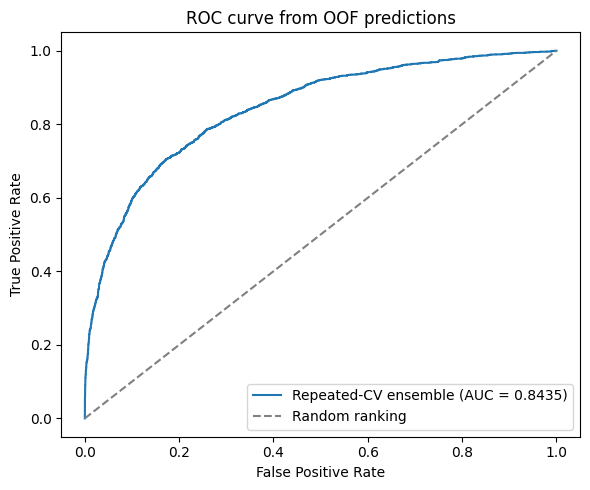

In [15]:
seed_diagnostics_df = pd.DataFrame(seed_diagnostics)
display(seed_diagnostics_df.round(6))

overall_auc = roc_auc_score(y, oof_predictions)
cat_repeated_auc = roc_auc_score(y, cat_oof_mean)
spline_repeated_auc = roc_auc_score(y, spline_oof_mean)

print(f"Repeated CatBoost OOF ROC-AUC: {round(cat_repeated_auc, 5)}")
print(f"Repeated Spline OOF ROC-AUC:   {round(spline_repeated_auc, 5)}")
print(f"Final ensemble OOF ROC AUC: {round(overall_auc, 5)}")

false_positive_rate, true_positive_rate, _ = roc_curve(y, oof_predictions)
plt.figure(figsize=(6, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Repeated-CV ensemble (AUC = {round(overall_auc, 4)})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random ranking")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve from OOF predictions")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
ensemble_diagnostics = pd.DataFrame(
    {
        "component": ["CatBoost repeated CV", "Spline repeated CV", "Final ensemble"],
        "weight": [CATBOOST_WEIGHT, SPLINE_WEIGHT, 1.0],
        "oof_roc_auc": [cat_repeated_auc, spline_repeated_auc, overall_auc],
    }
)
display(ensemble_diagnostics.round(6))

print("Best weights by mean AUC across the three split seeds:")
display(
    weight_search_results.sort_values(
        "mean_seed_auc", ascending=False
    ).head(10).round(6)
)


,component,weight,oof_roc_auc
0,CatBoost repeated CV,0.325,0.839987
1,Spline repeated CV,0.675,0.842211
2,Final ensemble,1.000,0.843454


Best weights by mean AUC across the three split seeds:


,catboost_weight,mean_seed_auc,min_seed_auc,max_seed_auc
13,0.325,0.843017,0.842928,0.843180
14,0.350,0.843007,0.842915,0.843187
12,0.300,0.843005,0.842924,0.843146
15,0.375,0.842995,0.842886,0.843187
11,0.275,0.842985,0.842887,0.843110
16,0.400,0.842957,0.842844,0.843163
10,0.250,0.842949,0.842860,0.843059
17,0.425,0.842913,0.842768,0.843142
9,0.225,0.842899,0.842816,0.842985
18,0.450,0.842847,0.842689,0.843109


## 9. Export and compare

The CSV must contain `application_id` and `target`, with one prediction for every test application. I check the identifiers, order and score range before saving. The original submitted CSV stays in the project root as a reference. A fresh run writes to `outputs/submission.csv` and reports the largest absolute difference from that reference.

Matching the saved file requires the original data, fixed settings and compatible library versions. The comparison also reports whether the two CSV files are byte identical.


In [17]:
submission = pd.DataFrame({
    "application_id": test["application_id"],
    "target": test_predictions,
})
assert list(submission.columns) == ["application_id", "target"]
assert len(submission) == len(test)
assert submission["application_id"].is_unique
assert submission["application_id"].equals(test["application_id"])
assert np.isfinite(submission["target"]).all()
assert submission["target"].between(0.0, 1.0).all()

output_dir = ROOT / "outputs"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "submission.csv"
submission.to_csv(output_path, index=False)

reference_path = ROOT / "submission.csv"
reference = pd.read_csv(reference_path)
assert list(reference.columns) == ["application_id", "target"]
assert reference["application_id"].equals(submission["application_id"])
assert np.isfinite(reference["target"]).all()
assert reference["target"].between(0.0, 1.0).all()
max_absolute_delta = np.abs(
    submission["target"].to_numpy() - reference["target"].to_numpy()
).max()
print("Saved:", output_path.relative_to(ROOT))
print("Rows:", len(submission))
print("Maximum absolute difference from submitted scores:", max_absolute_delta)
print("Matches reference within 1e-12:", max_absolute_delta <= 1e-12)
print("Byte identical to submitted CSV:", output_path.read_bytes() == reference_path.read_bytes())
display(submission["target"].describe().to_frame())


Saved: outputs/submission.csv
Rows: 2520
Maximum absolute difference from submitted scores: 1.1102230246251565e-16
Matches reference within 1e-12: True
Byte identical to submitted CSV: True


,target
count,2520.000000
mean,0.500198
std,0.287100
min,0.000526
25%,0.249000
50%,0.498834
75%,0.749222
max,0.999914
